## 1. Load Data And Baseline Audit

Check the raw shape, missing values, duplicate rows, duplicate `order_id`s, and target balance before cleaning.

Load the dataset and display a quick baseline summary.

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)
df = pd.read_csv("/content/ecommerce_returns.csv")
df.head()

,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
0,ORD010306,CUST04587,43.0,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes
1,ORD012251,CUST02016,33.0,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,NaN,No
2,ORD004778,CUST01696,33.0,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,NaN,No
3,ORD016871,CUST00739,43.0,Female,Electronics,561.73,1,15.10,upi,Next-Day,1.0,0,4.8,0.138,Size/fit issue,Yes
4,ORD018385,CUST03850,40.0,Male,Sports,47.84,5,18.66,Debit Card,Next-Day,2.0,1,5.0,0.070,NaN,No


## 2. Exact Duplicate Rows

Remove rows that are identical across every column.

Count how many fully identical rows exist.

In [3]:
# Exact duplicate rows
df.duplicated().sum()

np.int64(40)

Drop exact duplicates and confirm none remain.

In [4]:
before_rows = len(df)
exact_duplicates = df.duplicated().sum()

df = df.drop_duplicates().copy()

print(f"Exact duplicate rows removed: {exact_duplicates}")
print(f"Rows before: {before_rows}")
print(f"Rows after: {len(df)}")
print(f"Remaining exact duplicates: {df.duplicated().sum()}")

Exact duplicate rows removed: 40
Rows before: 20000
Rows after: 19960
Remaining exact duplicates: 0


## 3. Duplicate `order_id`

`order_id` should identify one transaction. After exact duplicates are removed, any remaining duplicate `order_id`s are conflicting transaction records.

Show the conflicting order_id rows, then keep only the first occurrence.


In [5]:
duplicate_order_rows = df[df["order_id"].duplicated(keep=False)].sort_values("order_id")

print(f"Rows with duplicate order_id: {len(duplicate_order_rows)}")
display(duplicate_order_rows.head(10))

df = df.drop_duplicates(subset="order_id", keep="first").copy()

print(f"Remaining duplicate order_id count: {df['order_id'].duplicated().sum()}")
print(f"Rows after order_id cleaning: {len(df)}")

Rows with duplicate order_id: 40


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
12251,ORD001138,CUST04079,NaN,Female,Sports,50.24,2,32.12,UPI,Express,5.0,1,3.4,0.182,NaN,No
8629,ORD001138,CUST04079,NaN,Female,Sports,50.24,2,32.12,UPI,Express,4.0,1,4.2,0.182,NaN,No
17843,ORD002614,CUST01651,29.0,Female,Fashion,48.01,1,4.66,Debit Card,Express,3.0,0,4.1,0.191,NaN,No
16752,ORD002614,CUST01651,29.0,Female,Fashion,48.01,1,4.66,Debit Card,Express,4.0,0,4.9,0.191,NaN,No
14576,ORD004960,CUST00553,52.0,NaN,Electronics,450.07,1,30.52,Credit Card,Express,5.0,2,4.1,0.062,NaN,No
11706,ORD004960,CUST00553,52.0,NaN,Electronics,450.07,1,30.52,Credit Card,Express,7.0,2,4.9,0.062,NaN,No
9363,ORD006331,CUST00983,59.0,Male,Groceries,50.81,1,35.99,Cash on Delivery,Standard,7.0,2,3.2,0.093,NaN,No
6357,ORD006331,CUST00983,59.0,Male,Groceries,50.81,1,35.99,Cash on Delivery,Standard,8.0,2,2.4,0.093,NaN,No
19170,ORD007551,CUST03360,35.0,Female,Beauty,61.74,1,21.06,Debit Card,Express,3.0,0,4.9,0.376,NaN,No
9346,ORD007551,CUST03360,35.0,Female,Beauty,61.74,1,21.06,Debit Card,Express,4.0,0,4.1,0.376,NaN,No


Remaining duplicate order_id count: 0
Rows after order_id cleaning: 19940


## 4. Standardize `product_category`

First check whether the same product categories appear with different spelling, casing, or extra spaces. Then map them into one clean set of categories.

Show raw category values — many variants for the same real category.

In [6]:
df["product_category"].value_counts(dropna=False)

,count
product_category,
Fashion,4522
Electronics,3600
Home & Living,2968
Beauty,2392
Sports,2109
Books,1940
Groceries,1911
FASHION,41
fashion,40


Map every variant to one of the 7 standard category labels.

In [7]:
category_map = {
    "electronics": "Electronics",
    "fashion": "Fashion",
    "home and living": "Home & Living",
    "sports": "Sports",
    "books": "Books",
    "beauty": "Beauty",
    "groceries": "Groceries",
    "grocery": "Groceries",
}

df["product_category"] = (
    df["product_category"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "and", regex=False)
    .map(category_map)
)

Confirm the column now has exactly 7 clean categories.

In [8]:
df["product_category"].value_counts(dropna=False)

,count
product_category,
Fashion,4632
Electronics,3681
Home & Living,3051
Beauty,2456
Sports,2163
Groceries,1980
Books,1977


## 5. Standardize `customer_gender`

First check whether gender values are split across inconsistent labels such as `F`, `M`, lowercase text, extra spaces, or missing values. Then standardize them.

Show raw gender values — inconsistent casing, abbreviations, blanks.

In [9]:
df["customer_gender"].value_counts(dropna=False)

,count
customer_gender,
Female,9646
Male,8455
Other,950
NaN,598
Female,55
female,48
M,48
F,44
Male,44


Standardize to Female / Male / Other / Unknown.

In [10]:
gender_map = {
    "female": "Female",
    "f": "Female",
    "male": "Male",
    "m": "Male",
    "other": "Other",
    "unknown": "Unknown",
}

df["customer_gender"] = (
    df["customer_gender"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .map(gender_map)
    .fillna("Unknown")
)

Confirm the column has only the 4 expected gender labels.

In [11]:
df["customer_gender"].value_counts(dropna=False)

,count
customer_gender,
Female,9793
Male,8590
Other,956
Unknown,601


## 6. Standardize `payment_method`

First check whether the same payment method appears under multiple labels. Then map each alias to one canonical payment method.

Show raw payment values — aliases like COD, upi, creditcard.

In [12]:
df["payment_method"].value_counts(dropna=False)

,count
payment_method,
Credit Card,6074
Debit Card,4516
Wallet,3484
Cash on Delivery,3227
UPI,2044
NaN,199
credit card,44
wallet,43
CREDIT CARD,39


Map every alias to one of the 5 canonical payment labels.

In [13]:
payment_map = {
    "credit card": "Credit Card",
    "creditcard": "Credit Card",
    "debit card": "Debit Card",
    "debitcard": "Debit Card",
    "wallet": "Wallet",
    "cash on delivery": "Cash on Delivery",
    "cod": "Cash on Delivery",
    "upi": "UPI",
}

df["payment_method"] = (
    df["payment_method"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("_", " ", regex=False)
    .map(payment_map)
    .fillna("Unknown")
)

Confirm the column is clean.

In [14]:
df["payment_method"].value_counts(dropna=False)

,count
payment_method,
Credit Card,6195
Debit Card,4616
Wallet,3553
Cash on Delivery,3292
UPI,2085
Unknown,199


## 7. Fix `return_reason` And `returned` Consistency

`return_reason` should agree with `returned`.

- If `returned = No`, set `return_reason` to `"Not Returned"`.
- If `returned = Yes` and `return_reason` is missing, set it to `"Not Specified"`.

Count rows where return_reason conflicts with the returned flag.

In [15]:
problem_counts = pd.Series({
    "No but has return_reason": ((df["returned"] == "No") & df["return_reason"].notna()).sum(),
    "Yes but missing return_reason": ((df["returned"] == "Yes") & df["return_reason"].isna()).sum()
})

problem_counts

,0
No but has return_reason,192
Yes but missing return_reason,98


Apply the two consistency rules.

In [16]:
df.loc[df["returned"] == "No", "return_reason"] = "Not Returned"

df.loc[
    (df["returned"] == "Yes") & (df["return_reason"].isna()),
    "return_reason"
] = "Not Specified"

Validate — both conflict counts must be 0.

In [17]:
validation_counts = pd.Series({
    "No but has real return_reason": ((df["returned"] == "No") & (df["return_reason"] != "Not Returned")).sum(),
    "Yes but missing return_reason": ((df["returned"] == "Yes") & df["return_reason"].isna()).sum()
})

validation_counts

,0
No but has real return_reason,0
Yes but missing return_reason,0


## 8. Age fix

Distribution and boxplot before fixing invalid ages.

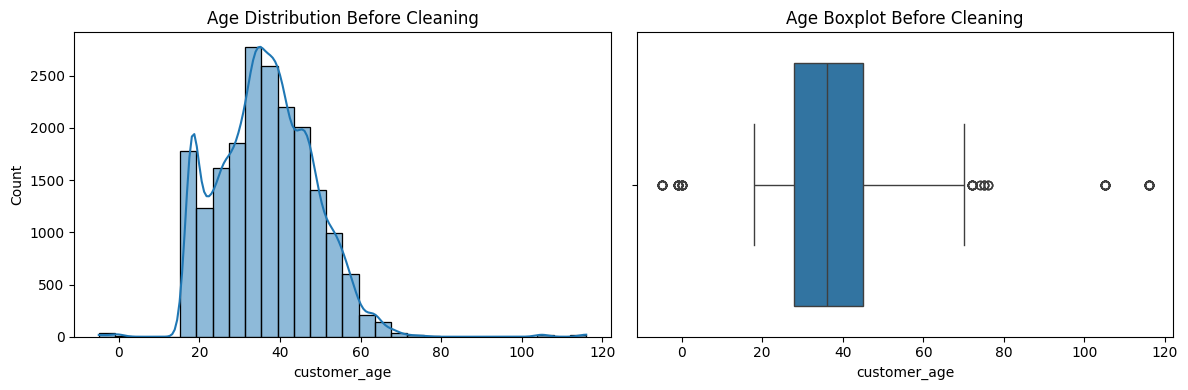

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_age"], bins=30, kde=True)
plt.title("Age Distribution Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_age"])
plt.title("Age Boxplot Before Cleaning")

plt.tight_layout()
plt.show()

Replace out-of-range age values (< 18 or > 80) with NaN.

In [23]:
df['customer_age'].isna().sum()

np.int64(398)

In [24]:
df.groupby(["customer_gender", "product_category"]).size().describe()

,0
count,28.000000
mean,712.142857
std,689.980714
min,41.000000
25%,107.250000
50%,544.500000
75%,1117.250000
max,2297.000000


In [25]:
import numpy as np

np.random.seed(42)

# ---------------------------------------------------
# Preserve original age
# ---------------------------------------------------
df["customer_age_original"] = df["customer_age"]

# ---------------------------------------------------
# Flag invalid ages
# ---------------------------------------------------
df["customer_age_status"] = "Valid"

df.loc[df["customer_age"] < 18, "customer_age_status"] = "Below 18"

df.loc[df["customer_age"] > 80, "customer_age_status"] = "Above 80"

# ---------------------------------------------------
# Convert invalid values to missing
# ---------------------------------------------------
df.loc[
    (df["customer_age"] < 18) |
    (df["customer_age"] > 80),
    "customer_age"
] = np.nan

# ---------------------------------------------------
# Track imputed rows
# ---------------------------------------------------
df["customer_age_imputed"] = df["customer_age"].isna()

# ---------------------------------------------------
# Random sampling within Gender + Product Category
# ---------------------------------------------------
for (gender, category), group in df.groupby(
    ["customer_gender", "product_category"]
):

    missing_idx = group[group["customer_age"].isna()].index

    valid_ages = group.loc[
        group["customer_age"].between(18,80),
        "customer_age"
    ]

    if len(valid_ages) > 0:

        sampled = np.random.choice(
            valid_ages,
            size=len(missing_idx),
            replace=True
        )

        df.loc[missing_idx, "customer_age"] = sampled

# ---------------------------------------------------
# Fallback (should rarely execute)
# ---------------------------------------------------
remaining = df["customer_age"].isna()

overall_valid = df.loc[
    df["customer_age"].between(18,80),
    "customer_age"
]

df.loc[remaining,"customer_age"] = np.random.choice(
    overall_valid,
    size=remaining.sum(),
    replace=True
)

# ---------------------------------------------------
# Final formatting
# ---------------------------------------------------
df["customer_age"] = (
    df["customer_age"]
    .round()
    .astype(int)
)

# ---------------------------------------------------
# Validation
# ---------------------------------------------------
assert df["customer_age"].between(18,80).all()

print("✓ Customer age cleaned successfully")
print(df["customer_age_status"].value_counts())
print("\nRows imputed:", df["customer_age_imputed"].sum())

✓ Customer age cleaned successfully
customer_age_status
Valid       19860
Below 18       41
Above 80       39
Name: count, dtype: int64

Rows imputed: 478


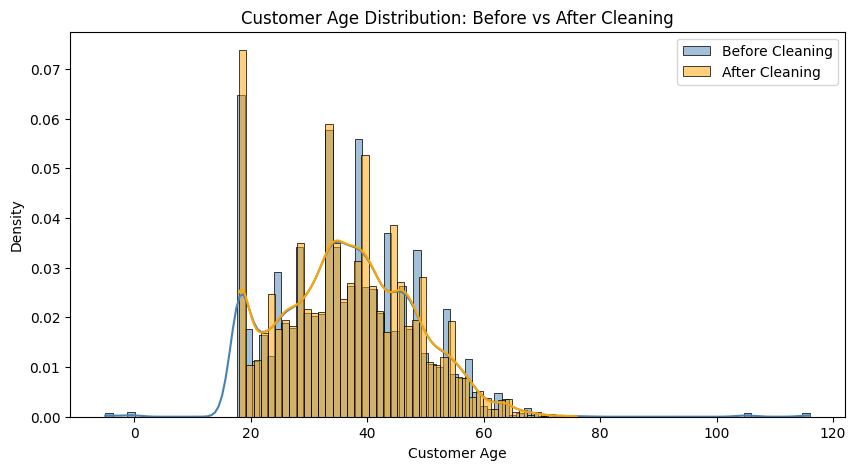

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df["customer_age_original"].dropna(),
    color="steelblue",
    label="Before Cleaning",
    kde=True,
    stat="density",
    alpha=0.5
)

sns.histplot(
    df["customer_age"],
    color="orange",
    label="After Cleaning",
    kde=True,
    stat="density",
    alpha=0.5
)

plt.title("Customer Age Distribution: Before vs After Cleaning")
plt.xlabel("Customer Age")
plt.legend()
plt.show()

In [28]:
#Ks test
from scipy.stats import ks_2samp

before = df["customer_age_original"].dropna()
after = df["customer_age"]

ks, p = ks_2samp(before, after)

print("KS Statistic:", round(ks,4))
print("P-value:", round(p,4))

KS Statistic: 0.0021
P-value: 1.0


Distribution Preserved

In [30]:
# Optional: Keep a backup before final cleanup
df_backup = df.copy()

# Drop temporary validation columns
df.drop(
    columns=[
        "customer_age_original",
        "customer_age_status",
        "customer_age_imputed"
    ],
    inplace=True
)

# Verify
df.head()

,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
0,ORD010306,CUST04587,43,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes
1,ORD012251,CUST02016,33,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,Not Returned,No
2,ORD004778,CUST01696,33,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,Not Returned,No
3,ORD016871,CUST00739,43,Female,Electronics,561.73,1,15.10,UPI,Next-Day,1.0,0,4.8,0.138,Size/fit issue,Yes
4,ORD018385,CUST03850,40,Male,Sports,47.84,5,18.66,Debit Card,Next-Day,2.0,1,5.0,0.070,Not Returned,No


Validate — no missing, none below 18 or above 80.

In [31]:
pd.Series({
    "missing_customer_age": df["customer_age"].isna().sum(),
    "below_18": (df["customer_age"] < 18).sum(),
    "above_80": (df["customer_age"] > 80).sum()
})

,0
missing_customer_age,0
below_18,0
above_80,0


Distribution and boxplot after cleaning.

## 9. Fix invalid customer_rating

Identify rows with ratings outside the valid 1–5 scale.

In [32]:
invalid_rating = df[
    df["customer_rating"].isna() |
    (df["customer_rating"] < 1) |
    (df["customer_rating"] > 5)
]

print("Invalid or missing customer_rating rows:", len(invalid_rating))
invalid_rating[["product_category", "customer_rating"]].head()

Invalid or missing customer_rating rows: 677


,product_category,customer_rating
58,Beauty,NaN
71,Fashion,NaN
116,Sports,NaN
154,Groceries,NaN
181,Books,NaN


Distribution and boxplot before fixing.

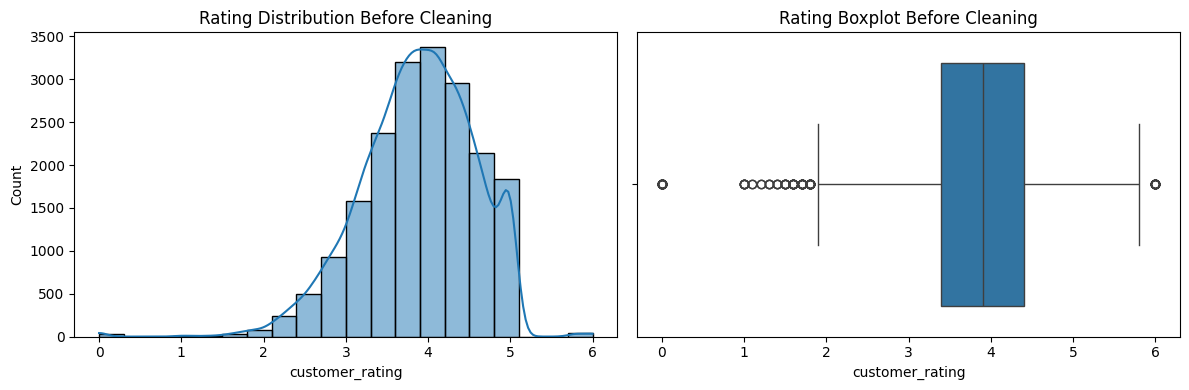

In [33]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_rating"], bins=20, kde=True)
plt.title("Rating Distribution Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_rating"])
plt.title("Rating Boxplot Before Cleaning")

plt.tight_layout()
plt.show()

Convert invalid ratings to NaN, then fill with category-wise median.

In [34]:
df.loc[
    (df["customer_rating"] < 1) | (df["customer_rating"] > 5),
    "customer_rating"
] = pd.NA

category_rating_median = df.groupby("product_category")["customer_rating"].transform("median")

df["customer_rating"] = (
    df["customer_rating"]
    .fillna(category_rating_median)
    .fillna(df["customer_rating"].median())
)

Validate — no missing, none outside 1–5.

In [35]:
rating_validation = pd.Series({
    "missing_customer_rating": df["customer_rating"].isna().sum(),
    "below_1": (df["customer_rating"] < 1).sum(),
    "above_5": (df["customer_rating"] > 5).sum()
})

rating_validation

,0
missing_customer_rating,0
below_1,0
above_5,0


Distribution and boxplot after cleaning.

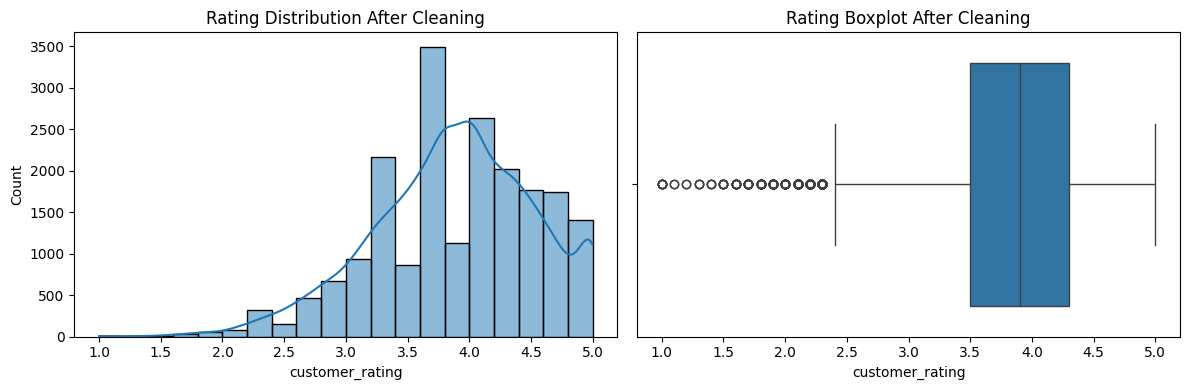

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["customer_rating"], bins=20, kde=True)
plt.title("Rating Distribution After Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["customer_rating"])
plt.title("Rating Boxplot After Cleaning")

plt.tight_layout()
plt.show()

## 10. Fix invalid discount_percent

Identify rows with discount values below 0 or above 100.

In [37]:
invalid_discount = df[
    (df["discount_percent"] < 0) |
    (df["discount_percent"] > 100)
]

print("Invalid discount_percent rows:", len(invalid_discount))
invalid_discount[["discount_percent"]].head()

Invalid discount_percent rows: 80


,discount_percent
311,-10.0
482,-3.0
514,-3.0
574,105.0
1211,-3.0


Distribution and boxplot before clipping.

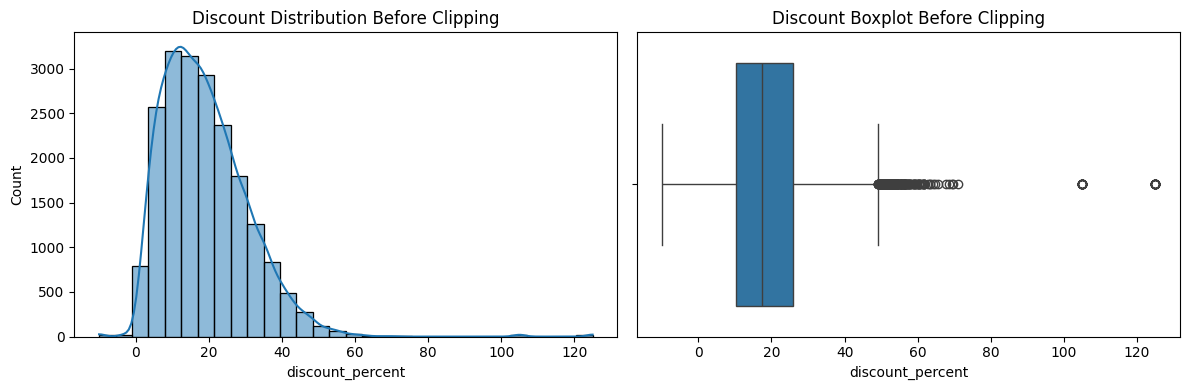

In [38]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["discount_percent"], bins=30, kde=True)
plt.title("Discount Distribution Before Clipping")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["discount_percent"])
plt.title("Discount Boxplot Before Clipping")

plt.tight_layout()
plt.show()

Clip negative discounts to 0 and values above 100 to 100.

In [39]:
df["discount_percent"] = df["discount_percent"].clip(lower=0, upper=100)

Validate — no values below 0 or above 100.

In [40]:
discount_validation = pd.Series({
    "below_0": (df["discount_percent"] < 0).sum(),
    "above_100": (df["discount_percent"] > 100).sum()
})

discount_validation

,0
below_0,0
above_100,0


Distribution and boxplot after clipping.

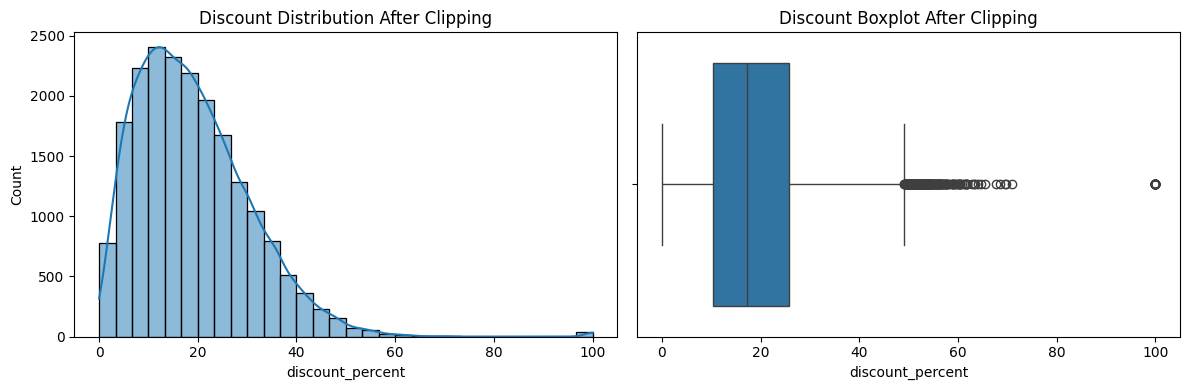

In [41]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["discount_percent"], bins=30, kde=True)
plt.title("Discount Distribution After Clipping")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["discount_percent"])
plt.title("Discount Boxplot After Clipping")

plt.tight_layout()
plt.show()

## 11. Fix delivery time and delay issues

Count missing delivery_time_days and extreme delay values.

In [42]:
delivery_issue_counts = pd.Series({
    "missing_delivery_time": df["delivery_time_days"].isna().sum(),
    "delivery_time_less_than_1": (df["delivery_time_days"] < 1).sum(),
    "early_delivery_delay_minus_1": (df["delivery_delay_days"] == -1).sum(),
    "extreme_delay_above_10": (df["delivery_delay_days"] > 10).sum()
})

delivery_issue_counts

,0
missing_delivery_time,299
delivery_time_less_than_1,60
early_delivery_delay_minus_1,1578
extreme_delay_above_10,117


Boxplots of both delivery columns before cleaning.

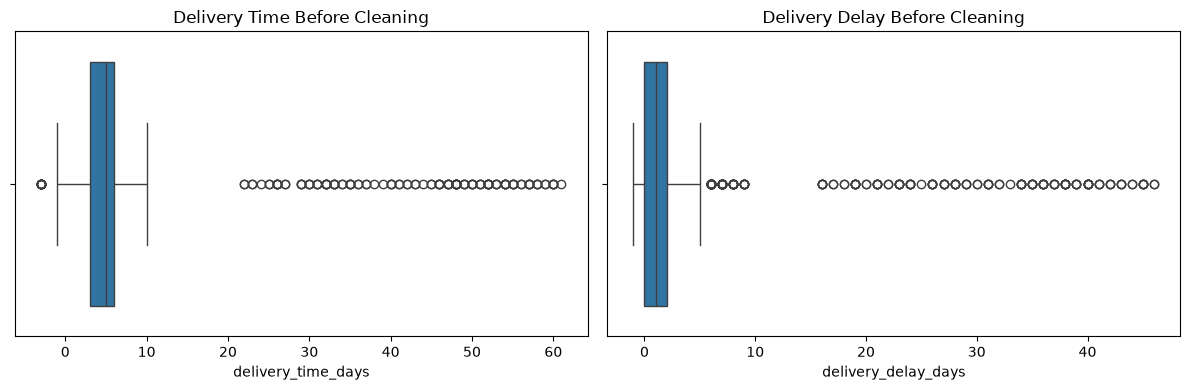

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["delivery_time_days"])
plt.title("Delivery Time Before Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["delivery_delay_days"])
plt.title("Delivery Delay Before Cleaning")

plt.tight_layout()
plt.show()

Convert delivery_time_days < 1 to NaN.

In [43]:
df.loc[df["delivery_time_days"] < 1, "delivery_time_days"] = pd.NA

Reconstruct missing delivery_time_days from shipping method + delay.

In [44]:
expected_days = {
    "Standard": 5,
    "Express": 3,
    "Next-Day": 1
}

reconstructed_delivery_time = (
    df["shipping_method"].map(expected_days) + df["delivery_delay_days"]
).clip(lower=1)

df["delivery_time_days"] = df["delivery_time_days"].fillna(reconstructed_delivery_time)

Flag orders where delivery delay exceeds 10 days.

In [45]:
df["is_extreme_delivery_delay"] = df["delivery_delay_days"] > 10

Validate — no missing delivery_time_days, check flag count.

In [46]:
delivery_validation = pd.Series({
    "missing_delivery_time": df["delivery_time_days"].isna().sum(),
    "delivery_time_less_than_1": (df["delivery_time_days"] < 1).sum(),
    "early_delivery_delay_minus_1": (df["delivery_delay_days"] == -1).sum(),
    "extreme_delay_flagged": df["is_extreme_delivery_delay"].sum()
})

delivery_validation

,0
missing_delivery_time,0
delivery_time_less_than_1,0
early_delivery_delay_minus_1,1578
extreme_delay_flagged,117


Boxplots after cleaning.

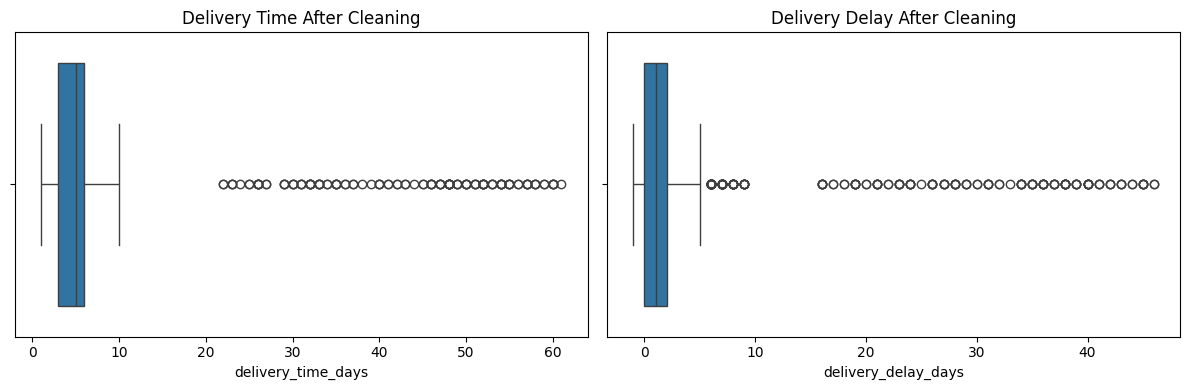

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["delivery_time_days"])
plt.title("Delivery Time After Cleaning")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["delivery_delay_days"])
plt.title("Delivery Delay After Cleaning")

plt.tight_layout()
plt.show()

## 12.  Impute missing customer fields

Check which customer-level fields still have missing values.

In [52]:
customer_fields = ["customer_age", "customer_gender", "past_return_rate"]

df[customer_fields].isna().sum()

,0
customer_age,0
customer_gender,0
past_return_rate,199


Fill missing past_return_rate from same customer_id, then global median.

In [57]:
customer_return_rate_median = df.groupby("customer_id")["past_return_rate"].transform("median")

df["past_return_rate"] = (
    df["past_return_rate"]
    .fillna(customer_return_rate_median)
    .fillna(df["past_return_rate"].median())
)

Second pass to catch any remaining past_return_rate gaps.

In [58]:
customer_return_rate_median = df.groupby("customer_id")["past_return_rate"].transform("median")

df["past_return_rate"] = (
    df["past_return_rate"]
    .fillna(customer_return_rate_median)
    .fillna(df["past_return_rate"].median())
)

## 13.  Impute missing transaction fields

Check which transaction-level fields still have missing values.

In [59]:
transaction_fields = [
    "payment_method",
    "delivery_time_days",
    "customer_rating",
    "discount_percent"
]

df[transaction_fields].isna().sum()

,0
payment_method,0
delivery_time_days,0
customer_rating,0
discount_percent,0


In [63]:
df[transaction_fields].isna().sum()

,0
payment_method,0
delivery_time_days,0
customer_rating,0
discount_percent,0


## 14. Handle/flag outliers

IQR-based outlier count for each numeric column — informational only.

In [64]:
numeric_cols = [
    "customer_age",
    "product_price",
    "order_quantity",
    "discount_percent",
    "delivery_time_days",
    "delivery_delay_days",
    "customer_rating",
    "past_return_rate"
]

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,column,lower_bound,upper_bound,outlier_count
0,customer_age,2.50000,70.50000,21
1,product_price,-137.64125,348.78875,1680
2,order_quantity,-2.00000,6.00000,100
3,discount_percent,-13.01000,49.15000,238
4,delivery_time_days,-1.50000,10.50000,117
5,delivery_delay_days,-3.00000,5.00000,202
6,customer_rating,2.30000,5.50000,367
7,past_return_rate,-0.20650,0.51750,410


Create boolean flags for business-meaningful outliers.

In [65]:
df["is_high_value_product"] = df["product_price"] > df["product_price"].quantile(0.99)
df["is_bulk_order"] = df["order_quantity"] > 10
df["is_extreme_delivery_delay"] = df["delivery_delay_days"] > 10

df[["is_high_value_product", "is_bulk_order", "is_extreme_delivery_delay"]].sum()

,0
is_high_value_product,200
is_bulk_order,100
is_extreme_delivery_delay,117


In [66]:
df.describe()

,customer_age,product_price,order_quantity,discount_percent,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate
count,19940.000000,19940.000000,19940.000000,19940.000000,19940.000000,19940.000000,19940.000000,19940.000000
mean,36.533250,143.970099,2.203962,19.015756,5.021966,1.190471,3.873325,0.170753
std,11.322874,216.822280,3.107931,11.598354,3.604712,2.822717,0.657071,0.133036
min,18.000000,6.720000,1.000000,0.000000,1.000000,-1.000000,1.000000,0.000000
25%,28.000000,44.770000,1.000000,10.300000,3.000000,0.000000,3.500000,0.065000
50%,36.000000,82.755000,2.000000,17.340000,5.000000,1.000000,3.900000,0.140000
75%,45.000000,166.377500,3.000000,25.840000,6.000000,2.000000,4.300000,0.246000
max,76.000000,6373.070000,60.000000,100.000000,61.000000,46.000000,5.000000,0.744000


**Final Check Before EDA**

In [67]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Duplicate order IDs
print("Duplicate Order IDs:", df["order_id"].duplicated().sum())

# Numeric summary
display(df.describe().T)

# Categorical summary
display(df.describe(include="object").T)

order_id                     0
customer_id                  0
customer_age                 0
customer_gender              0
product_category             0
product_price                0
order_quantity               0
discount_percent             0
payment_method               0
shipping_method              0
delivery_time_days           0
delivery_delay_days          0
customer_rating              0
past_return_rate             0
return_reason                0
returned                     0
is_extreme_delivery_delay    0
is_high_value_product        0
is_bulk_order                0
dtype: int64
Duplicate Rows: 0
Duplicate Order IDs: 0


,count,mean,std,min,25%,50%,75%,max
customer_age,19940.0,36.533250,11.322874,18.00,28.000,36.000,45.0000,76.000
product_price,19940.0,143.970099,216.822280,6.72,44.770,82.755,166.3775,6373.070
order_quantity,19940.0,2.203962,3.107931,1.00,1.000,2.000,3.0000,60.000
discount_percent,19940.0,19.015756,11.598354,0.00,10.300,17.340,25.8400,100.000
delivery_time_days,19940.0,5.021966,3.604712,1.00,3.000,5.000,6.0000,61.000
delivery_delay_days,19940.0,1.190471,2.822717,-1.00,0.000,1.000,2.0000,46.000
customer_rating,19940.0,3.873325,0.657071,1.00,3.500,3.900,4.3000,5.000
past_return_rate,19940.0,0.170753,0.133036,0.00,0.065,0.140,0.2460,0.744


,count,unique,top,freq
order_id,19940,19940,ORD009805,1
customer_id,19940,4410,CUST04289,64
customer_gender,19940,4,Female,9793
product_category,19940,7,Fashion,4632
payment_method,19940,6,Credit Card,6195
shipping_method,19940,3,Standard,10835
return_reason,19940,8,Not Returned,16036
returned,19940,2,No,16036


In [69]:
print("="*50)
print("FINAL DATA VALIDATION")
print("="*50)

print(f"Shape                : {df.shape}")
print(f"Missing Values       : {df.isnull().sum().sum()}")
print(f"Duplicate Rows       : {df.duplicated().sum()}")
print(f"Duplicate Order IDs  : {df['order_id'].duplicated().sum()}")

print("\nData Types")
display(df.dtypes)

FINAL DATA VALIDATION
Shape                : (19940, 19)
Missing Values       : 0
Duplicate Rows       : 0
Duplicate Order IDs  : 0

Data Types


,0
order_id,object
customer_id,object
customer_age,int64
customer_gender,object
product_category,object
product_price,float64
order_quantity,int64
discount_percent,float64
payment_method,object
shipping_method,object


In [70]:
df.to_csv(
    "Retail_Return_Behaviour_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [71]:
df_clean = pd.read_csv("Retail_Return_Behaviour_Cleaned.csv")

print(df_clean.shape)
display(df_clean.head())

(19940, 19)


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned,is_extreme_delivery_delay,is_high_value_product,is_bulk_order
0,ORD010306,CUST04587,43,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes,False,False,False
1,ORD012251,CUST02016,33,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,Not Returned,No,False,False,False
2,ORD004778,CUST01696,33,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,Not Returned,No,False,False,False
3,ORD016871,CUST00739,43,Female,Electronics,561.73,1,15.10,UPI,Next-Day,1.0,0,4.8,0.138,Size/fit issue,Yes,False,False,False
4,ORD018385,CUST03850,40,Male,Sports,47.84,5,18.66,Debit Card,Next-Day,2.0,1,5.0,0.070,Not Returned,No,False,False,False


# Clean Dataset Export

After completing data quality assessment and preprocessing, the cleaned dataset was exported as **Retail_Return_Behaviour_Cleaned.csv**.

Cleaning performed includes:

- Removed duplicate orders
- Treated invalid customer ages using business rules
- Imputed missing customer ages using group-wise random sampling
- Corrected invalid discounts
- Corrected invalid customer ratings
- Imputed missing payment methods
- Imputed missing customer ratings
- Imputed missing past return rates
- Validated missing values, duplicates, and business constraints

This cleaned dataset will be used for all subsequent Exploratory Data Analysis (EDA), dashboard creation, and business recommendations.

# **Exploratory Data Analysis**

**Understand the Target Variable**


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


In [73]:
df_clean=pd.read_csv('/content/Retail_Return_Behaviour_Cleaned.csv')

/tmp/ipykernel_9714/821953526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


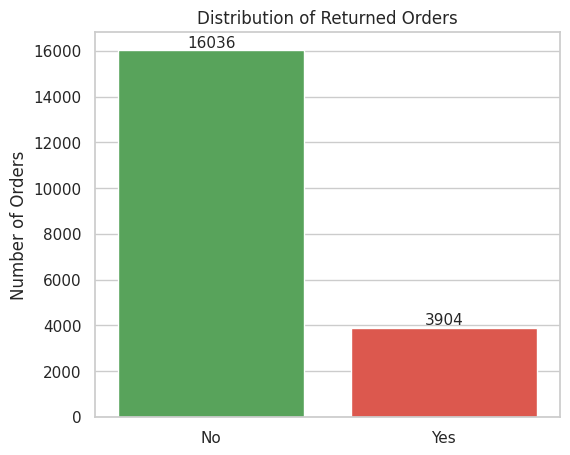

In [75]:
#Return Distribution
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df_clean,
    x="returned",
    order=["No","Yes"],
    palette=["#4CAF50","#F44336"]
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Returned Orders")
plt.xlabel("")
plt.ylabel("Number of Orders")

plt.show()

In [76]:
#Return KPI
summary = (
    df_clean["returned"]
    .value_counts()
    .rename_axis("Returned")
    .reset_index(name="Orders")
)

summary["Percentage"] = (
    summary["Orders"] /
    summary["Orders"].sum()*100
)

display(summary)

,Returned,Orders,Percentage
0,No,16036,80.421264
1,Yes,3904,19.578736


In [77]:
return_rate = (
    df_clean["returned"]
    .eq("Yes")
    .mean()*100
)

print(f"Overall Return Rate : {return_rate:.2f}%")

Overall Return Rate : 19.58%


*Nearly 20% of all fulfilled orders are returned, which can have a substantial impact on operational costs, reverse logistics, inventory management, and customer service.*

**Customer Behaviour**

/tmp/ipykernel_9714/1192126301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


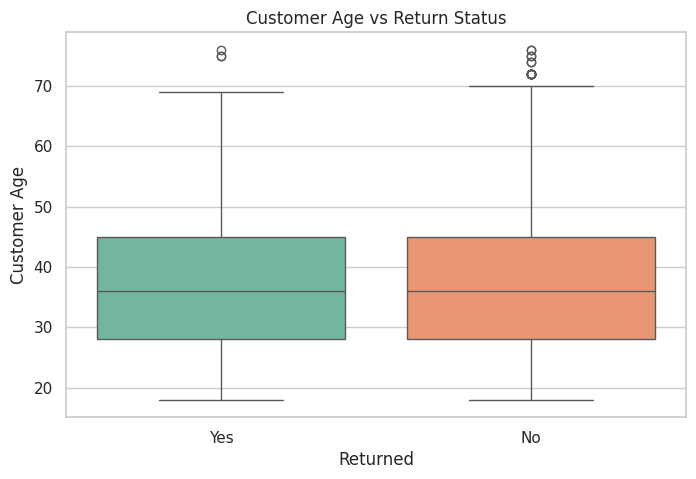

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
No,16036.0,36.536293,11.324584,18.0,28.0,36.0,45.0,76.0
Yes,3904.0,36.520748,11.317290,18.0,28.0,36.0,45.0,76.0


In [78]:
#Customer Age
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="returned",
    y="customer_age",
    palette="Set2"
)

plt.title("Customer Age vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Customer Age")

plt.show()

# Statistical summary
display(
    df_clean.groupby("returned")["customer_age"].describe()
)

*Customers of different age groups exhibit very similar return behaviour. Therefore, age is unlikely to be a useful variable for customer segmentation or for designing return-reduction strategies.*

returned,No,Yes
customer_gender,,
Female,79.67,20.33
Male,81.29,18.71
Other,81.90,18.10
Unknown,77.87,22.13


/tmp/ipykernel_9714/1530897534.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


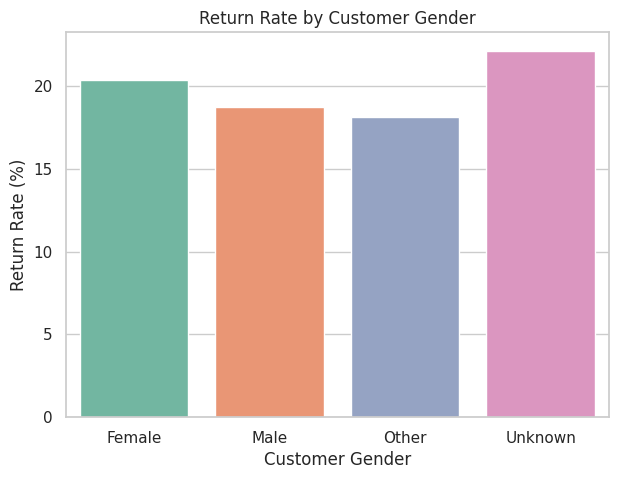

In [79]:
#Gender
# Return percentage by gender
gender_return = (
    pd.crosstab(
        df_clean["customer_gender"],
        df_clean["returned"],
        normalize="index"
    ) * 100
)

display(gender_return.round(2))

# Plot
plt.figure(figsize=(7,5))

sns.barplot(
    data=(gender_return["Yes"]
          .reset_index()
          .rename(columns={"Yes":"Return Rate (%)"})),
    x="customer_gender",
    y="Return Rate (%)",
    palette="Set2"
)

plt.title("Return Rate by Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Return Rate (%)")

plt.show()

In [80]:
df_clean["customer_gender"].value_counts()

,count
customer_gender,
Female,9793
Male,8590
Other,956
Unknown,601


**We should statistically validate whether gender and return behaviour are associated**

In [81]:
#Chii square Test
from scipy.stats import chi2_contingency

table = pd.crosstab(df_clean["customer_gender"], df_clean["returned"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic :", round(chi2,2))
print("P-value :", p)

Chi-square Statistic : 11.47
P-value : 0.009416589196146826


In [82]:
import numpy as np

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print("Cramer's V :", round(cramers_v,3))

Cramer's V : 0.024


*Although gender shows a statistically significant association with returns, the effect size is negligible (Cramér's V = 0).*

*This indicates that gender explains very little variation in customer return behaviour.*

**Past Return Behaviour**

In [83]:
df_clean.groupby("returned")["past_return_rate"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
No,16036.0,0.162,0.127,0.0,0.061,0.131,0.231,0.744
Yes,3904.0,0.208,0.149,0.0,0.087,0.178,0.304,0.744


/tmp/ipykernel_9714/1664292918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


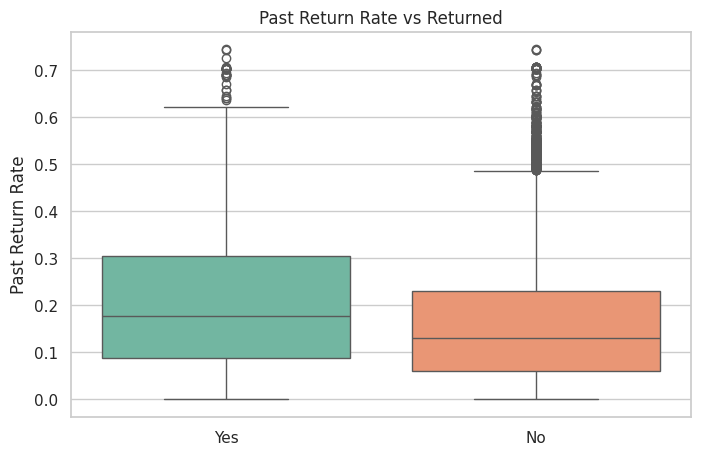

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="returned",
    y="past_return_rate",
    palette="Set2"
)

plt.title("Past Return Rate vs Returned")
plt.xlabel("")
plt.ylabel("Past Return Rate")

plt.show()

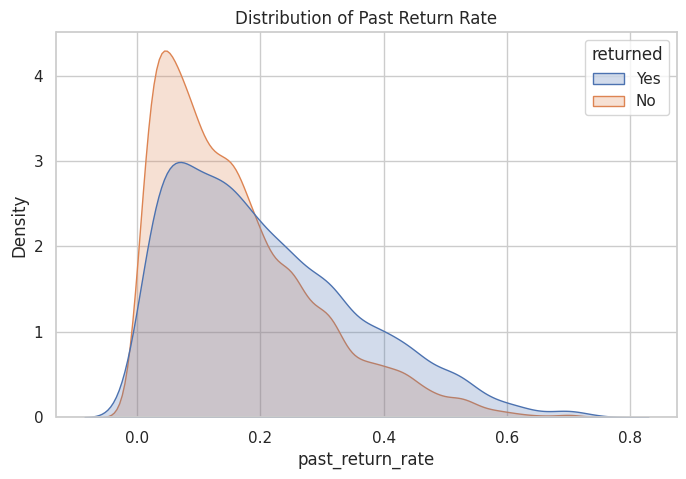

In [85]:
#Distribution
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean,
    x="past_return_rate",
    hue="returned",
    fill=True,
    common_norm=False
)

plt.title("Distribution of Past Return Rate")
plt.show()

In [86]:
# Mann-Whitney U test(Reight skewed)
from scipy.stats import mannwhitneyu

returned = df_clean[df_clean["returned"]=="Yes"]["past_return_rate"]
not_returned = df_clean[df_clean["returned"]=="No"]["past_return_rate"]

u, p = mannwhitneyu(returned, not_returned)

print("Mann-Whitney U:", u)
print("P-value:", p)

Mann-Whitney U: 37057413.5
P-value: 3.263843128408327e-71


In [87]:
print(
    df_clean.groupby("returned")["past_return_rate"]
    .agg(["mean","median","std"])
)

              mean  median       std
returned                            
No        0.161691   0.131  0.127338
Yes       0.207979   0.178  0.148575


    The mean difference is noticeable.

    The distribution itself shifts.

    Both statistics and visualization support the same conclusion.

    This makes past_return_rate one of the strongest behavioural variables we've examined so far.

    Customers with a higher historical return rate are considerably more likely to return future purchases.

This suggests that return behaviour is persistent rather than random



**Product Category**

In [88]:
# Return rate by product category
category_return = (
    pd.crosstab(
        df_clean["product_category"],
        df_clean["returned"],
        normalize="index"
    ) * 100
)

category_return = category_return.sort_values("Yes", ascending=False)

display(category_return.round(2))

returned,No,Yes
product_category,,
Fashion,72.37,27.63
Electronics,78.16,21.84
Beauty,79.36,20.64
Home & Living,82.83,17.17
Sports,83.31,16.69
Books,88.42,11.58
Groceries,89.95,10.05


/tmp/ipykernel_9714/2893623565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


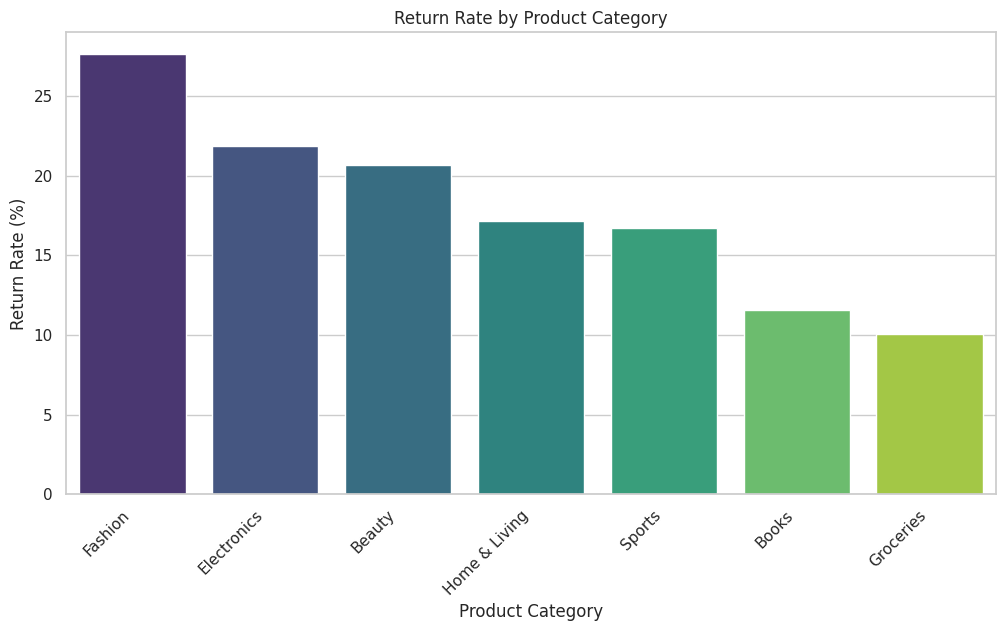

In [89]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_return.index,
    y=category_return["Yes"],
    palette="viridis"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Return Rate (%)")
plt.xlabel("Product Category")
plt.title("Return Rate by Product Category")

plt.show()

In [91]:
#Statistical Significance
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(df_clean["product_category"], df_clean["returned"])

chi2, p, dof, expected = chi2_contingency(table)

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print("Chi-square:", round(chi2,2))
print("P-value:", p)
print("Cramer's V:", round(cramers_v,3))

Chi-square: 421.72
P-value: 5.972907089212142e-88
Cramer's V: 0.145


    Fashion products are returned almost three times more frequently than groceries.

    This pattern aligns with real-world e-commerce behaviour

    Although not a "strong" effect statistically, it represents a practically useful business relationship because product category is directly actionable.

In [93]:
#Business ranking dashboard
category_summary = (
    df_clean.groupby("product_category")
    .agg(
        Total_Orders=("returned", "count"),
        Returned_Orders=("returned", lambda x: (x == "Yes").sum()),
        Return_Rate=("returned", lambda x: (x == "Yes").mean() * 100)
    )
    .sort_values("Return_Rate", ascending=False)
)

category_summary["Return_Rate"] = category_summary["Return_Rate"].round(2)

display(category_summary)

,Total_Orders,Returned_Orders,Return_Rate
product_category,,,
Fashion,4632,1280,27.63
Electronics,3681,804,21.84
Beauty,2456,507,20.64
Home & Living,3051,524,17.17
Sports,2163,361,16.69
Books,1977,229,11.58
Groceries,1980,199,10.05


**Delivery Behaviour Analysis**

In [94]:
#Summary Stats
df_clean.groupby("returned")["delivery_delay_days"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
No,16036.0,1.00,2.76,-1.0,0.0,0.0,2.0,46.0
Yes,3904.0,1.99,2.95,-1.0,0.0,2.0,3.0,46.0


/tmp/ipykernel_9714/214177349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


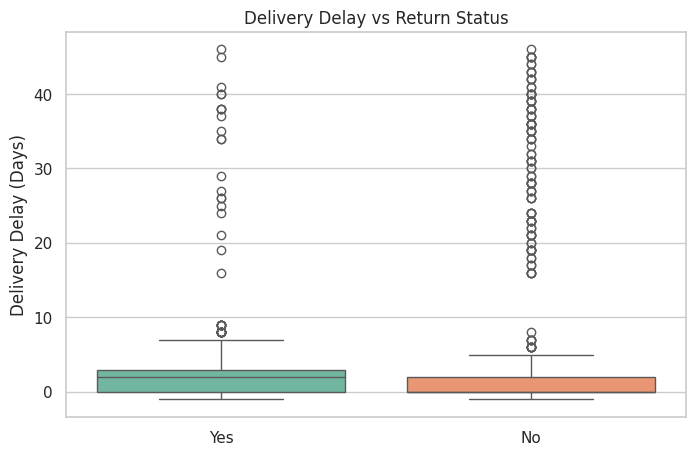

In [95]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="returned",
    y="delivery_delay_days",
    palette="Set2"
)

plt.title("Delivery Delay vs Return Status")
plt.xlabel("")
plt.ylabel("Delivery Delay (Days)")

plt.show()

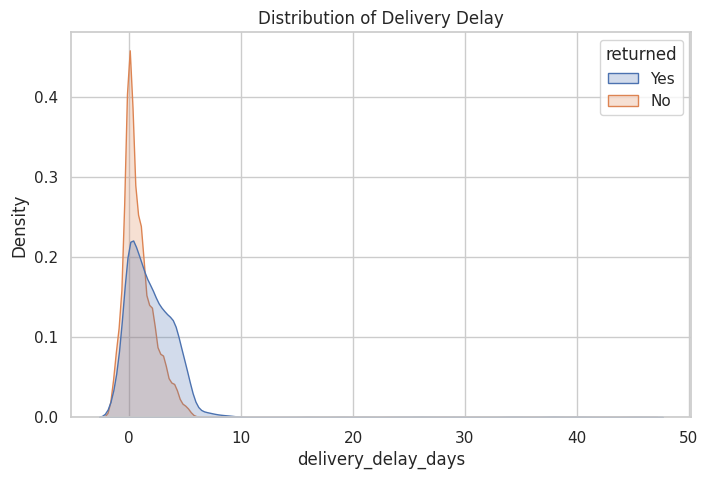

In [96]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean,
    x="delivery_delay_days",
    hue="returned",
    fill=True,
    common_norm=False
)

plt.title("Distribution of Delivery Delay")
plt.show()

In [97]:
#Statistical Test(Skewed)
from scipy.stats import mannwhitneyu

returned = df_clean[df_clean["returned"]=="Yes"]["delivery_delay_days"]
not_returned = df_clean[df_clean["returned"]=="No"]["delivery_delay_days"]

u,p = mannwhitneyu(returned, not_returned)

print("Mann-Whitney U :",u)
print("P-value :",p)

Mann-Whitney U : 41396269.0
P-value : 1.3912499318829225e-233


In [98]:
n1 = len(returned)
n2 = len(not_returned)

rank_biserial = 1 - (2*u)/(n1*n2)

print("Rank Biserial Correlation :",round(rank_biserial,3))

Rank Biserial Correlation : -0.322


In [101]:
#Return Rate Changes with Delay
delay_analysis = (
    df_clean.groupby("delivery_delay_days")
    .agg(
        Orders=("returned","count"),
        Return_Rate=("returned",lambda x:(x=="Yes").mean()*100)
    )
    .reset_index()
)

display(delay_analysis.head())

,delivery_delay_days,Orders,Return_Rate
0,-1,1578,12.167300
1,0,8109,12.134665
2,1,4229,17.711043
3,2,2632,23.784195
4,3,1632,31.188725


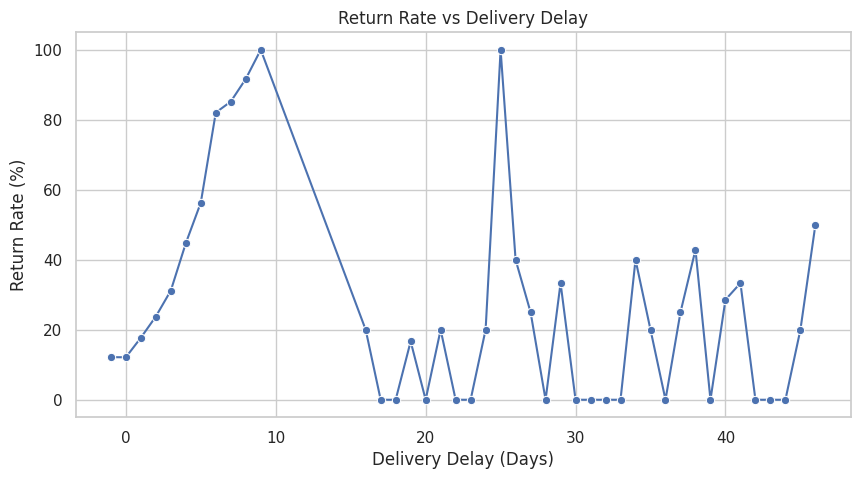

In [100]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=delay_analysis,
    x="delivery_delay_days",
    y="Return_Rate",
    marker="o"
)

plt.title("Return Rate vs Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Return Rate (%)")

plt.grid(True)

plt.show()

    Delivery performance appears to be one of the strongest operational drivers of product returns.

    Unlike customer demographics, delivery delay is under the company's control.

    Reducing delays could potentially reduce return rates while also improving customer satisfaction.

**Discount Strategy**

In [102]:
df_clean.groupby("returned")["discount_percent"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
No,16036.0,18.86,11.46,0.0,10.28,17.21,25.61,100.0
Yes,3904.0,19.65,12.13,0.0,10.41,17.88,26.67,100.0


/tmp/ipykernel_9714/1255501116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


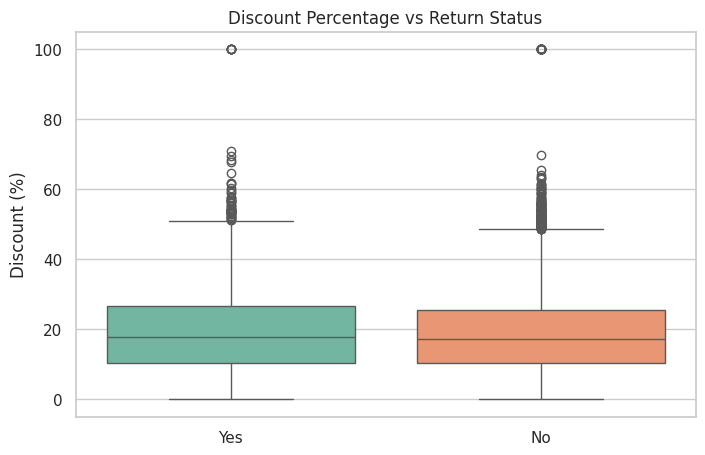

In [103]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="returned",
    y="discount_percent",
    palette="Set2"
)

plt.title("Discount Percentage vs Return Status")
plt.xlabel("")
plt.ylabel("Discount (%)")

plt.show()

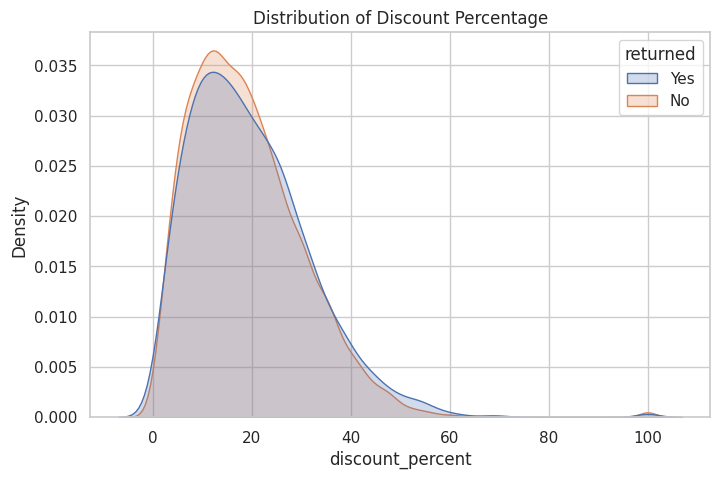

In [104]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean,
    x="discount_percent",
    hue="returned",
    fill=True,
    common_norm=False
)

plt.title("Distribution of Discount Percentage")
plt.show()

In [105]:
from scipy.stats import mannwhitneyu

returned = df_clean[df_clean["returned"]=="Yes"]["discount_percent"]
not_returned = df_clean[df_clean["returned"]=="No"]["discount_percent"]

u, p = mannwhitneyu(returned, not_returned)

print("Mann–Whitney U:", u)
print("P-value:", p)

rank_biserial = 1 - (2*u)/(len(returned)*len(not_returned))
print("Rank Biserial Correlation:", round(abs(rank_biserial), 3))

Mann–Whitney U: 32288567.0
P-value: 0.00222906564066118
Rank Biserial Correlation: 0.032


    discount percentage has minimal practical influence on return behaviour in this dataset

**Customer Rating**

In [106]:
df_clean["rating_bucket"] = pd.cut(
    df_clean["customer_rating"],
    bins=[0,2,3,4,5],
    labels=[
        "Poor (≤2)",
        "Average (2-3)",
        "Good (3-4)",
        "Excellent (4-5)"
    ],
    include_lowest=True
)

rating_summary = (
    pd.crosstab(
        df_clean["rating_bucket"],
        df_clean["returned"],
        normalize="index"
    )*100
)

display(rating_summary.round(2))

returned,No,Yes
rating_bucket,,
Poor (≤2),29.69,70.31
Average (2-3),59.47,40.53
Good (3-4),80.57,19.43
Excellent (4-5),86.44,13.56


/tmp/ipykernel_9714/4048687954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


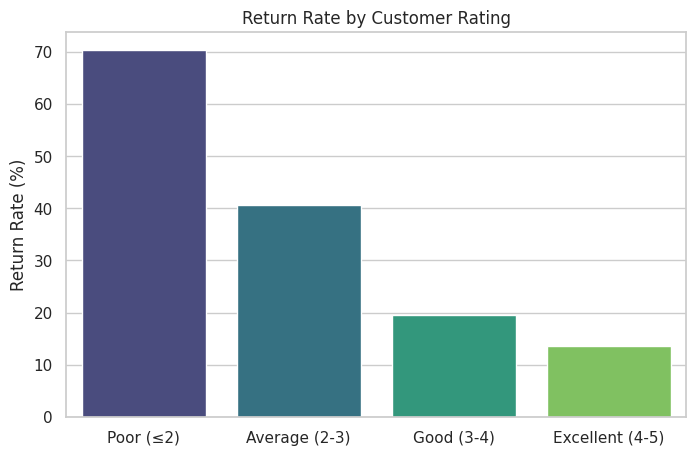

In [107]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_summary.index,
    y=rating_summary["Yes"],
    palette="viridis"
)

plt.ylabel("Return Rate (%)")
plt.xlabel("")
plt.title("Return Rate by Customer Rating")

plt.show()

    Customers giving poor ratings are

    almost five times more likely to return their purchase than customers giving excellent ratings

**Shipping Method vs Returns **

In [108]:
shipping_return = (
    pd.crosstab(
        df_clean["shipping_method"],
        df_clean["returned"],
        normalize="index"
    ) * 100
)

shipping_return = shipping_return.sort_values("Yes", ascending=False)

display(shipping_return.round(2))

returned,No,Yes
shipping_method,,
Next-Day,74.45,25.55
Standard,81.15,18.85
Express,82.20,17.80


In [109]:
shipping_summary = (
    df_clean.groupby("shipping_method")
    .agg(
        Total_Orders=("returned", "count"),
        Returned_Orders=("returned", lambda x: (x=="Yes").sum()),
        Return_Rate=("returned", lambda x: (x=="Yes").mean()*100)
    )
    .sort_values("Return_Rate", ascending=False)
)

shipping_summary["Return_Rate"] = shipping_summary["Return_Rate"].round(2)

display(shipping_summary)

,Total_Orders,Returned_Orders,Return_Rate
shipping_method,,,
Next-Day,3116,796,25.55
Standard,10835,2042,18.85
Express,5989,1066,17.80


/tmp/ipykernel_9714/1207297695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


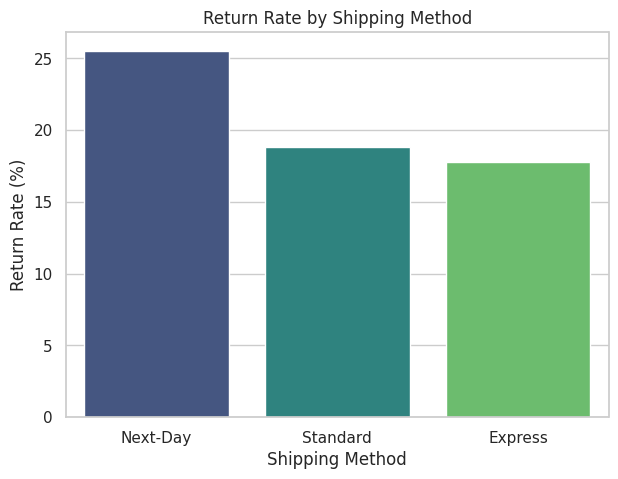

In [110]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=shipping_summary.reset_index(),
    x="shipping_method",
    y="Return_Rate",
    palette="viridis"
)

plt.ylabel("Return Rate (%)")
plt.xlabel("Shipping Method")
plt.title("Return Rate by Shipping Method")

plt.show()

In [111]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_clean["shipping_method"],
    df_clean["returned"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square :", round(chi2,2))
print("P-value :", p)

Chi-square : 86.19
P-value : 1.920528187408727e-19


In [112]:
import numpy as np

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(
    chi2/(n*(min(r-1,k-1)))
)

print("Cramer's V :", round(cramers_v,3))

Cramer's V : 0.066


In [113]:
payment_return = (
    pd.crosstab(
        df_clean["payment_method"],
        df_clean["returned"],
        normalize="index"
    ) * 100
)

payment_return = payment_return.sort_values("Yes", ascending=False)

display(payment_return.round(2))

returned,No,Yes
payment_method,,
Cash on Delivery,78.04,21.96
Credit Card,80.29,19.71
Debit Card,81.13,18.87
Wallet,81.26,18.74
UPI,81.44,18.56
Unknown,81.91,18.09


In [114]:
payment_summary = (
    df_clean.groupby("payment_method")
    .agg(
        Total_Orders=("returned","count"),
        Returned_Orders=("returned",lambda x:(x=="Yes").sum()),
        Return_Rate=("returned",lambda x:(x=="Yes").mean()*100)
    )
    .sort_values("Return_Rate",ascending=False)
)

payment_summary["Return_Rate"] = payment_summary["Return_Rate"].round(2)

display(payment_summary)

,Total_Orders,Returned_Orders,Return_Rate
payment_method,,,
Cash on Delivery,3292,723,21.96
Credit Card,6195,1221,19.71
Debit Card,4616,871,18.87
Wallet,3553,666,18.74
UPI,2085,387,18.56
Unknown,199,36,18.09


/tmp/ipykernel_9714/3207506210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


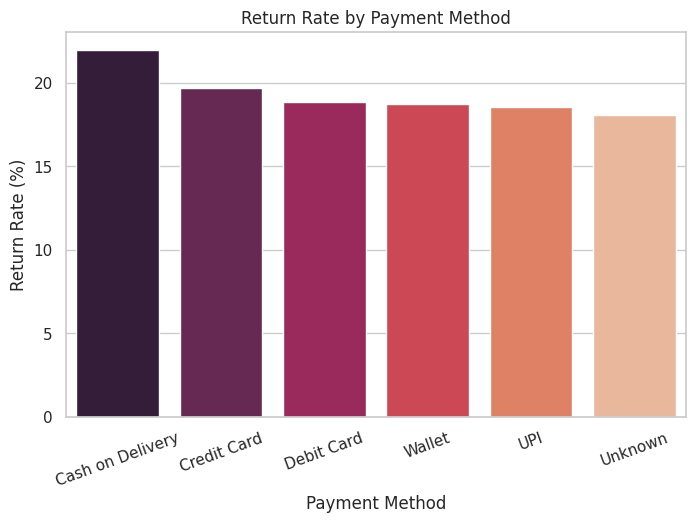

In [115]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_summary.reset_index(),
    x="payment_method",
    y="Return_Rate",
    palette="rocket"
)

plt.xticks(rotation=20)

plt.ylabel("Return Rate (%)")
plt.xlabel("Payment Method")

plt.title("Return Rate by Payment Method")

plt.show()